# Recurrent Neural Networks (RNNs)

All networks so far assume **fixed-size inputs** — an image always has H×W pixels.  
Many real-world problems involve **sequences** of variable length:

```
  Text:        "The cat sat on the mat."  (7 words)
  Time series: [1.2, 1.5, 0.8, 1.1, ...]  (T timesteps)
  Audio:       [0.01, 0.02, -0.01, ...]    (44,100 samples/sec)
  DNA:         ATCGATCGTTACG               (variable length)
```

An MLP or CNN cannot directly handle these because it has **no memory** — it processes each input independently.  
**Recurrent Neural Networks** solve this by maintaining a **hidden state** that summarizes all past inputs.

---
**Topics covered**
1. The vanishing gradient problem in sequences
2. RNN architecture — hidden state and unrolling through time
3. Backpropagation Through Time (BPTT)
4. Types of RNN tasks (many-to-one, one-to-many, many-to-many)
5. NumPy RNN from scratch — character-level language model
6. PyTorch RNN — sentiment analysis on movie reviews
7. Sequence generation — sampling from a trained language model
8. Time series forecasting with RNNs
9. The vanishing gradient problem in RNNs — motivation for LSTM/GRU
10. Summary

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset, TensorDataset
    TORCH = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch {torch.__version__} | device: {device}')
except ImportError:
    TORCH = False
    print('PyTorch not found — NumPy demos will still run.')

PyTorch 2.7.0 | device: cpu


## 1. Why Standard Networks Fail on Sequences

### The Problem with MLPs for Sequences

Consider classifying a review as positive or negative:

```
  Review 1: "The movie was great."
  Review 2: "Great... not. The movie was terrible."
```

A bag-of-words MLP sees both reviews as having similar features (both contain "great")  
but misses that **word order** and **context** completely change the meaning.

An MLP of fixed input size also can't handle reviews of different lengths.

### What We Need
1. **Memory** — remember what was said earlier in the sequence
2. **Variable-length input** — handle sequences of any length
3. **Shared weights across time** — the same word should be processed the same way regardless of position

In [2]:
# Demonstrate why word order matters (bag-of-words vs sequential)
from collections import Counter

reviews = [
    ("The movie was great", "positive"),
    ("Great not the movie was terrible", "negative"),
    ("Not great the movie was bad", "negative"),
    ("The movie was not great at all", "negative"),
]

print('Bag-of-Words representation (loses word order):')
print('-' * 55)
vocab = {'great', 'not', 'terrible', 'was', 'movie', 'the', 'bad', 'all', 'at'}
for text, label in reviews:
    words = text.lower().split()
    bow = {w: words.count(w) for w in vocab if w in words}
    print(f'  [{label}] "{text}"')
    print(f'           BoW: {bow}')
    print()

print('Note: "great not" and "not great" look similar in BoW!')
print('RNNs process word-by-word, maintaining context of what came before.')

Bag-of-Words representation (loses word order):
-------------------------------------------------------
  [positive] "The movie was great"
           BoW: {'was': 1, 'great': 1, 'the': 1, 'movie': 1}

  [negative] "Great not the movie was terrible"
           BoW: {'was': 1, 'great': 1, 'terrible': 1, 'the': 1, 'movie': 1, 'not': 1}

  [negative] "Not great the movie was bad"
           BoW: {'was': 1, 'bad': 1, 'great': 1, 'the': 1, 'movie': 1, 'not': 1}

  [negative] "The movie was not great at all"
           BoW: {'was': 1, 'great': 1, 'the': 1, 'all': 1, 'movie': 1, 'at': 1, 'not': 1}

Note: "great not" and "not great" look similar in BoW!
RNNs process word-by-word, maintaining context of what came before.


## 2. RNN Architecture — Hidden State

An RNN processes one element of the sequence at a time and maintains a **hidden state** `h_t` that acts as its memory.

```
  At each timestep t:

    h_t = tanh( W_hh · h_{t-1}  +  W_xh · x_t  +  b_h )
                ↑                    ↑
           previous hidden         current
           state (memory)          input

    y_t = W_hy · h_t  +  b_y    (output at this timestep, if needed)
```

### Unrolled through time (same weights W at every step):

```
  h₀ ──► RNN ──► h₁ ──► RNN ──► h₂ ──► RNN ──► h₃ ──► RNN ──► h₄
           ↑               ↑               ↑               ↑
           x₁              x₂              x₃              x₄
           ↓               ↓               ↓               ↓
           y₁              y₂              y₃              y₄     ← outputs (optional)

  Same W_hh, W_xh, b_h at every timestep — weight sharing through time
```

**Parameters:** independent of sequence length T!
$$\text{Params} = H^2 + H \cdot D + H + H \cdot Y + Y$$
where H = hidden size, D = input size, Y = output size

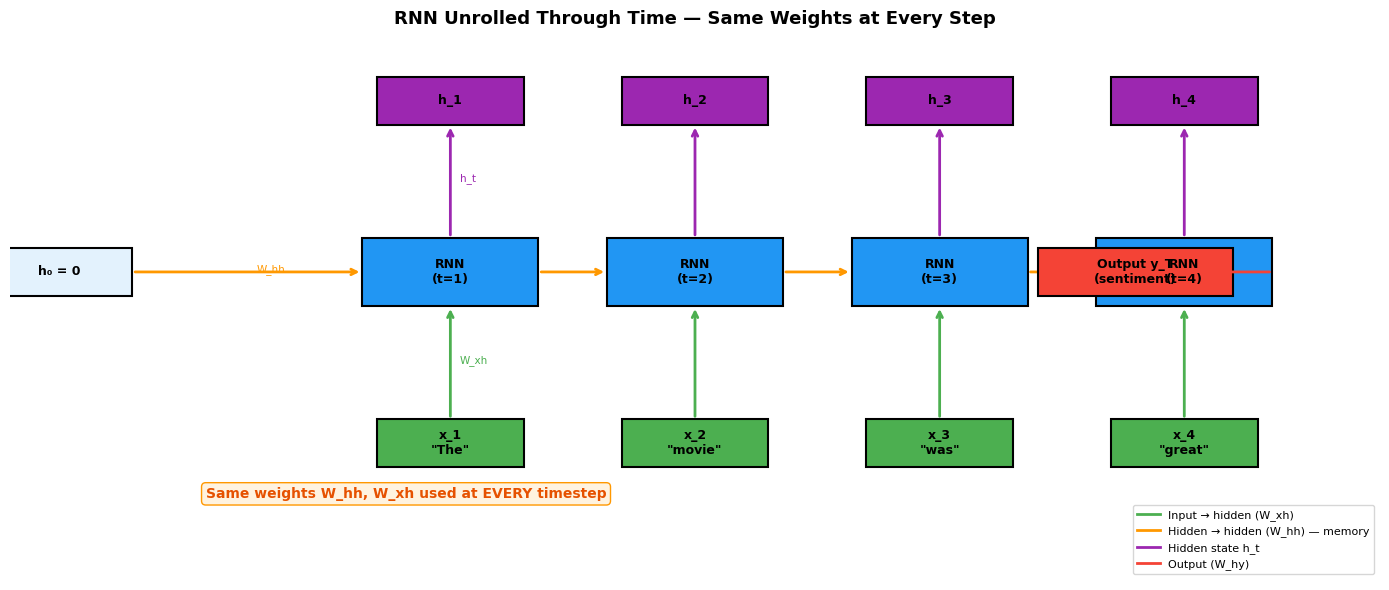

RNN parameters (H=128, D=50, Y=2):
  W_hh: 128×128 = 16,384
  W_xh: 128×50 = 6,400
  b_h:  128
  W_hy: 128×2 = 256
  b_y:  2
  Total: 23,170  (independent of sequence length T)


In [3]:
def draw_rnn_unrolled(T=4):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_xlim(0, 14); ax.set_ylim(0, 8)
    ax.axis('off')

    def box(x, y, w, h, label, color, fontsize=9):
        rect = plt.Rectangle((x-w/2, y-h/2), w, h,
                               facecolor=color, edgecolor='black', lw=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
                fontweight='bold', zorder=4)

    def arr(x1, y1, x2, y2, color='#333', label=''):
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
        if label:
            mx, my = (x1+x2)/2, (y1+y2)/2
            ax.text(mx+0.1, my, label, fontsize=7.5, color=color)

    xs = [2, 4.5, 7, 9.5, 12]

    # h0
    box(xs[0]-1.5, 4.5, 1.5, 0.7, 'h₀ = 0', '#E3F2FD')

    tokens = ['The', 'movie', 'was', 'great']
    for i, (x, tok) in enumerate(zip(xs[1:], tokens)):
        # RNN cell
        box(x, 4.5, 1.8, 1.0, f'RNN\n(t={i+1})', '#2196F3')
        # Input
        box(x, 2.0, 1.5, 0.7, f'x_{i+1}\n"{tok}"', '#4CAF50')
        arr(x, 2.35, x, 4.0, color='#4CAF50', label='W_xh' if i==0 else '')
        # Output / hidden state
        box(x, 7.0, 1.5, 0.7, f'h_{i+1}', '#9C27B0')
        arr(x, 5.0, x, 6.65, color='#9C27B0', label='h_t' if i==0 else '')

    # Horizontal hidden state arrows
    for i in range(len(xs)-1):
        if i == 0:
            arr(xs[0]-0.75, 4.5, xs[1]-0.9, 4.5, color='#FF9800', label='W_hh')
        else:
            arr(xs[i]+0.9, 4.5, xs[i+1]-0.9, 4.5, color='#FF9800')

    # Final output (sentiment)
    box(11.5, 4.5, 2.0, 0.7, 'Output y_T\n(sentiment)', '#F44336')
    arr(xs[-1]+0.9, 4.5, 10.5, 4.5, color='#F44336', label='W_hy')

    # Labels
    ax.text(2.0, 1.2, 'Same weights W_hh, W_xh used at EVERY timestep',
            fontsize=10, fontweight='bold', color='#E65100',
            bbox=dict(facecolor='#FFF3E0', edgecolor='#FF9800', boxstyle='round,pad=0.3'))

    legend_items = [
        plt.Line2D([0],[0], color='#4CAF50', lw=2, label='Input → hidden (W_xh)'),
        plt.Line2D([0],[0], color='#FF9800', lw=2, label='Hidden → hidden (W_hh) — memory'),
        plt.Line2D([0],[0], color='#9C27B0', lw=2, label='Hidden state h_t'),
        plt.Line2D([0],[0], color='#F44336', lw=2, label='Output (W_hy)'),
    ]
    ax.legend(handles=legend_items, loc='lower right', fontsize=8)
    ax.set_title('RNN Unrolled Through Time — Same Weights at Every Step',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_rnn_unrolled()

# Parameter count
H, D, Y = 128, 50, 2
params = H*H + H*D + H + H*Y + Y
print(f'RNN parameters (H={H}, D={D}, Y={Y}):')
print(f'  W_hh: {H}×{H} = {H*H:,}')
print(f'  W_xh: {H}×{D} = {H*D:,}')
print(f'  b_h:  {H:,}')
print(f'  W_hy: {H}×{Y} = {H*Y}')
print(f'  b_y:  {Y}')
print(f'  Total: {params:,}  (independent of sequence length T)')

## 3. Backpropagation Through Time (BPTT)

Training an RNN requires computing gradients **through time** — unrolling the recurrence and backpropagating like a deep feedforward network.

For a sequence of length T, the gradient of the loss with respect to W_hh involves a chain of products:

$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial h_t} \prod_{k=t}^{T-1} \frac{\partial h_{k+1}}{\partial h_k}$$

Each factor $\frac{\partial h_{k+1}}{\partial h_k}$ involves multiplying by $W_{hh}$ (and the tanh derivative).  

- If `|eigenvalues(W_hh)| < 1` → **Vanishing gradients** (early timesteps get no signal)
- If `|eigenvalues(W_hh)| > 1` → **Exploding gradients** (training diverges)

This is why vanilla RNNs struggle with **long-range dependencies** — information from 50+ steps ago is effectively lost.

**Partial solutions for vanilla RNNs:**
- Gradient clipping (for exploding)
- Truncated BPTT (only backprop through last K steps)
- Careful weight initialization (orthogonal initialization)

**Complete solution:** LSTM and GRU (next notebook)

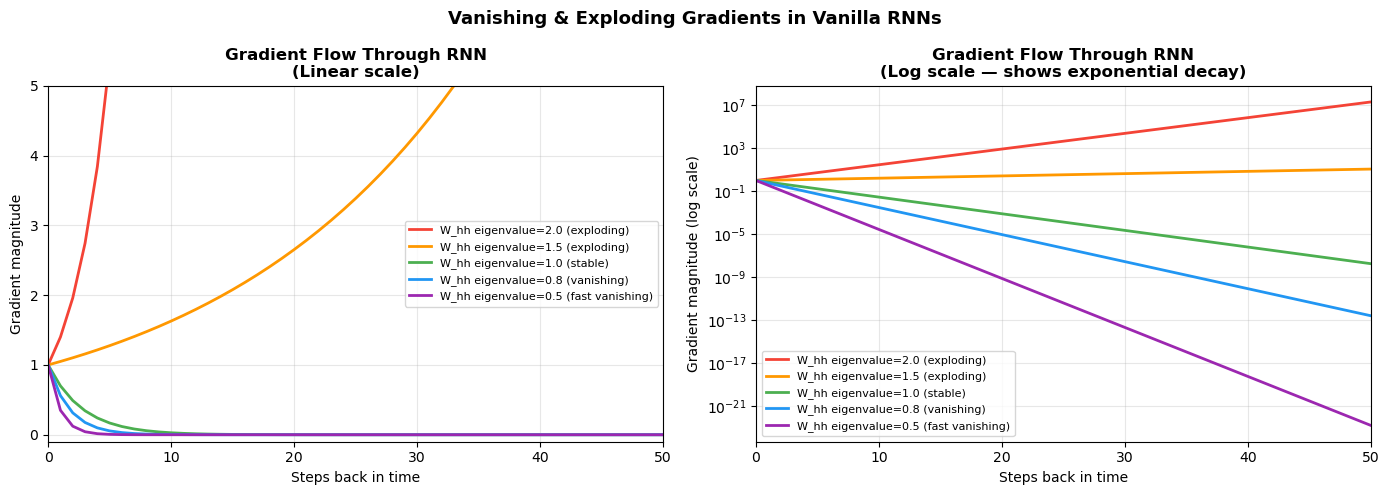

Key insight:
  After 50 steps, a gradient starting at 1.0 becomes:
    W_hh eigenvalue=2.0 (exploding   → 2.02e+07
    W_hh eigenvalue=1.5 (exploding   → 1.15e+01
    W_hh eigenvalue=1.0 (stable)     → 1.80e-08
    W_hh eigenvalue=0.8 (vanishing   → 2.57e-13
    W_hh eigenvalue=0.5 (fast vani   → 1.60e-23


In [4]:
# Demonstrate vanishing/exploding gradients in vanilla RNN
def simulate_gradient_flow(W_hh_eigenvalue, T=50):
    """Simulate how gradient magnitude changes over T steps."""
    grad = 1.0
    grads = [grad]
    for _ in range(T):
        # Each step multiplies gradient by (W_hh_eigenvalue * tanh_derivative)
        # tanh_derivative ≈ 0.7 at typical activations
        grad *= W_hh_eigenvalue * 0.7
        grads.append(abs(grad))
    return grads

configs = [
    (2.0,  '#F44336', 'W_hh eigenvalue=2.0 (exploding)'),
    (1.5,  '#FF9800', 'W_hh eigenvalue=1.5 (exploding)'),
    (1.0,  '#4CAF50', 'W_hh eigenvalue=1.0 (stable)'),
    (0.8,  '#2196F3', 'W_hh eigenvalue=0.8 (vanishing)'),
    (0.5,  '#9C27B0', 'W_hh eigenvalue=0.5 (fast vanishing)'),
]

T = 50
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for eigval, color, label in configs:
    grads = simulate_gradient_flow(eigval, T)
    ax1.plot(grads, color=color, lw=2, label=label)
    ax2.semilogy(grads, color=color, lw=2, label=label)

ax1.set_xlabel('Steps back in time'); ax1.set_ylabel('Gradient magnitude')
ax1.set_title('Gradient Flow Through RNN\n(Linear scale)', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_xlim(0, T); ax1.set_ylim(-0.1, 5)

ax2.set_xlabel('Steps back in time'); ax2.set_ylabel('Gradient magnitude (log scale)')
ax2.set_title('Gradient Flow Through RNN\n(Log scale — shows exponential decay)', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.set_xlim(0, T)

plt.suptitle('Vanishing & Exploding Gradients in Vanilla RNNs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key insight:')
print('  After 50 steps, a gradient starting at 1.0 becomes:')
for eigval, _, label in configs:
    final = (eigval * 0.7) ** 50
    print(f'    {label[:30]:<32} → {final:.2e}')

## 4. Types of RNN Tasks

RNNs are flexible — the input and output can be sequences of different lengths.

```
  Many-to-One         One-to-Many         Many-to-Many           Many-to-Many
  (seq → label)      (label → seq)       (equal length)         (encoder-decoder)

  x₁x₂x₃x₄ → y      x → y₁y₂y₃y₄      x₁x₂x₃ → y₁y₂y₃      x₁x₂ → y₁y₂y₃

  Sentiment           Image captioning    POS tagging             Machine translation
  analysis            Music generation    Named entity recog.     Summarization
  Text classification Video generation   Video frame labeling    Question answering
```

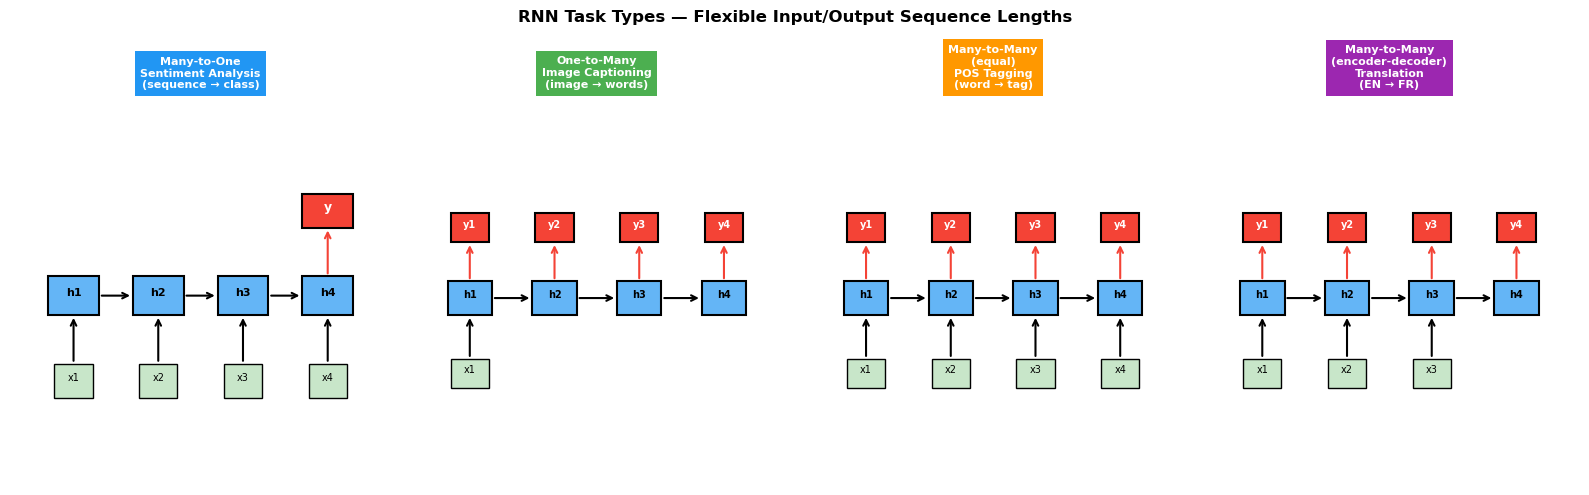

In [5]:
def draw_rnn_types():
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    configs = [
        ('Many-to-One', 4, 1, 'Sentiment Analysis\n(sequence → class)', '#2196F3'),
        ('One-to-Many', 1, 4, 'Image Captioning\n(image → words)', '#4CAF50'),
        ('Many-to-Many\n(equal)', 4, 4, 'POS Tagging\n(word → tag)', '#FF9800'),
        ('Many-to-Many\n(encoder-decoder)', 3, 4, 'Translation\n(EN → FR)', '#9C27B0'),
    ]

    for ax, (title, n_in, n_out, example, color) in zip(axes, configs):
        ax.set_xlim(0, 6); ax.set_ylim(0, 8)
        ax.axis('off')
        ax.set_title(f'{title}\n{example}', fontweight='bold', fontsize=8,
                     color='white', bbox=dict(facecolor=color, edgecolor='none', pad=4))

        T = max(n_in, n_out)
        xs = np.linspace(1, 5, T)

        if title.startswith('Many-to-One'):
            for i, x in enumerate(xs):
                c = '#64B5F6' if i < n_in else '#E0E0E0'
                ax.add_patch(plt.Rectangle((x-0.4, 3.5), 0.8, 0.8, facecolor=c, edgecolor='black', lw=1.5))
                if i < n_in:
                    ax.text(x, 3.9, f'h{i+1}', ha='center', fontsize=8, fontweight='bold')
                    ax.add_patch(plt.Rectangle((x-0.3, 1.8), 0.6, 0.7, facecolor='#C8E6C9', edgecolor='black', lw=1))
                    ax.text(x, 2.15, f'x{i+1}', ha='center', fontsize=7)
                    ax.annotate('', xy=(x, 3.5), xytext=(x, 2.5), arrowprops=dict(arrowstyle='->', lw=1.5))
                if i > 0 and i < n_in:
                    ax.annotate('', xy=(x-0.4, 3.9), xytext=(xs[i-1]+0.4, 3.9),
                                arrowprops=dict(arrowstyle='->', lw=1.5))
            last_x = xs[n_in-1]
            ax.add_patch(plt.Rectangle((last_x-0.4, 5.3), 0.8, 0.7, facecolor='#F44336', edgecolor='black', lw=1.5))
            ax.text(last_x, 5.65, 'y', ha='center', fontsize=9, fontweight='bold', color='white')
            ax.annotate('', xy=(last_x, 5.3), xytext=(last_x, 4.3), arrowprops=dict(arrowstyle='->', lw=1.5, color='#F44336'))

        else:
            for i in range(T):
                x = xs[i]
                ax.add_patch(plt.Rectangle((x-0.35, 3.5), 0.7, 0.7, facecolor='#64B5F6', edgecolor='black', lw=1.5))
                ax.text(x, 3.85, f'h{i+1}', ha='center', fontsize=7, fontweight='bold')
                if i > 0:
                    ax.annotate('', xy=(x-0.35, 3.85), xytext=(xs[i-1]+0.35, 3.85),
                                arrowprops=dict(arrowstyle='->', lw=1.5))
                if i < n_in:
                    ax.add_patch(plt.Rectangle((x-0.3, 2.0), 0.6, 0.6, facecolor='#C8E6C9', edgecolor='black', lw=1))
                    ax.text(x, 2.3, f'x{i+1}', ha='center', fontsize=7)
                    ax.annotate('', xy=(x, 3.5), xytext=(x, 2.6), arrowprops=dict(arrowstyle='->', lw=1.5))
                if i >= T - n_out:
                    ax.add_patch(plt.Rectangle((x-0.3, 5.0), 0.6, 0.6, facecolor='#F44336', edgecolor='black', lw=1.5))
                    ax.text(x, 5.3, f'y{i+1}', ha='center', fontsize=7, color='white', fontweight='bold')
                    ax.annotate('', xy=(x, 5.0), xytext=(x, 4.2), arrowprops=dict(arrowstyle='->', lw=1.5, color='#F44336'))

    plt.suptitle('RNN Task Types — Flexible Input/Output Sequence Lengths', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_rnn_types()

## 5. NumPy RNN from Scratch — Character-Level Language Model

We build a character-level RNN that learns to predict the next character in a text.  
After training, we can **sample** from it to generate new text in the style of the training data.

This is the classic Karpathy "min-char-rnn" — the simplest useful RNN.

In [6]:
# Character-level language model — NumPy RNN from scratch

# Training text
text = (
    "hello world this is a recurrent neural network learning to predict "
    "characters one step at a time the network remembers what it saw before "
    "and uses that memory to make better predictions about what comes next "
    "deep learning is fascinating and powerful neural networks can learn "
    "patterns from data automatically without being explicitly programmed "
) * 3  # repeat to give more data

# Build vocabulary
chars  = sorted(set(text))
vocab  = {c: i for i, c in enumerate(chars)}
idx2ch = {i: c for c, i in vocab.items()}
V      = len(chars)   # vocabulary size
H      = 64           # hidden state size

print(f'Text length: {len(text)} characters')
print(f'Vocabulary:  {V} unique characters: {repr("".join(chars))}')
print(f'Hidden size: {H}')


class VanillaRNN:
    """
    Minimal character-level RNN.
    Input: one-hot encoded characters
    Output: logits over vocabulary
    """
    def __init__(self, input_size, hidden_size, output_size, lr=1e-1):
        self.H  = hidden_size
        self.lr = lr
        scale   = 0.01
        self.Wxh = np.random.randn(hidden_size, input_size)  * scale
        self.Whh = np.random.randn(hidden_size, hidden_size) * scale
        self.Why = np.random.randn(output_size, hidden_size) * scale
        self.bh  = np.zeros((hidden_size, 1))
        self.by  = np.zeros((output_size, 1))

        # Adagrad memory
        self.mWxh = np.zeros_like(self.Wxh)
        self.mWhh = np.zeros_like(self.Whh)
        self.mWhy = np.zeros_like(self.Why)
        self.mbh  = np.zeros_like(self.bh)
        self.mby  = np.zeros_like(self.by)

    def forward(self, inputs, h_prev):
        """
        inputs: list of T integer character indices
        Returns: ys (logits per step), hs (hidden states), xs (one-hots)
        """
        xs, hs, ys, ps = {}, {}, {}, {}
        hs[-1] = h_prev.copy()
        for t, idx in enumerate(inputs):
            xs[t]  = np.zeros((V, 1)); xs[t][idx] = 1
            hs[t]  = np.tanh(self.Wxh @ xs[t] + self.Whh @ hs[t-1] + self.bh)
            ys[t]  = self.Why @ hs[t] + self.by
            e      = np.exp(ys[t] - ys[t].max())
            ps[t]  = e / e.sum()   # softmax
        return xs, hs, ys, ps

    def loss_and_grads(self, inputs, targets, h_prev):
        xs, hs, ys, ps = self.forward(inputs, h_prev)
        T = len(inputs)

        loss = sum(-np.log(ps[t][targets[t], 0]) for t in range(T))

        # BPTT
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh  = np.zeros_like(self.bh)
        dby  = np.zeros_like(self.by)
        dh_next = np.zeros_like(hs[0])

        for t in reversed(range(T)):
            dy         = ps[t].copy()
            dy[targets[t]] -= 1
            dWhy      += dy @ hs[t].T
            dby       += dy
            dh         = self.Why.T @ dy + dh_next
            dh_raw     = (1 - hs[t]**2) * dh    # tanh derivative
            dbh       += dh_raw
            dWxh      += dh_raw @ xs[t].T
            dWhh      += dh_raw @ hs[t-1].T
            dh_next    = self.Whh.T @ dh_raw

        for d in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(d, -5, 5, out=d)    # gradient clipping

        return loss, [dWxh, dWhh, dWhy, dbh, dby], hs[T-1]

    def update(self, grads):
        for param, grad, mem in zip(
            [self.Wxh, self.Whh, self.Why, self.bh, self.by],
            grads,
            [self.mWxh, self.mWhh, self.mWhy, self.mbh, self.mby]
        ):
            mem   += grad * grad
            param -= self.lr * grad / (np.sqrt(mem) + 1e-8)   # Adagrad

    def sample(self, h, seed_idx, n=100):
        """Generate n characters by sampling from the model."""
        x   = np.zeros((V, 1)); x[seed_idx] = 1
        out = [seed_idx]
        for _ in range(n - 1):
            h  = np.tanh(self.Wxh @ x + self.Whh @ h + self.bh)
            y  = self.Why @ h + self.by
            e  = np.exp(y - y.max()); p = (e / e.sum()).ravel()
            idx = np.random.choice(V, p=p)
            x  = np.zeros((V, 1)); x[idx] = 1
            out.append(idx)
        return ''.join(idx2ch[i] for i in out)

Text length: 1035 characters
Vocabulary:  23 unique characters: ' abcdefghiklmnoprstuwxy'
Hidden size: 64


Training character-level RNN...
  Step    0 | loss=78.388 | sample: "uuweusxemet mgfounueli monrmabneahmgrofroom phxtmedfkflcybxw"
  Step  500 | loss=70.803 | sample: "fhep ing iig al be teorengbey is omeatneartan ngres angat ce"
  Step 1000 | loss=56.268 | sample: "eutone le borep networkd inexnt ardis at meithe ratong bemsr"
  Step 1500 | loss=43.473 | sample: "errnititensrernit leerndeetlerfura nemomemkerrs ine fre eret"
  Step 2000 | loss=33.278 | sample: "re an tepr tow tho rsecurrexrneutto p lely mhetwory thautiic"
  Step 2500 | loss=25.699 | sample: "recint ong fbe tbes next deet learning eat chetholdy this se"


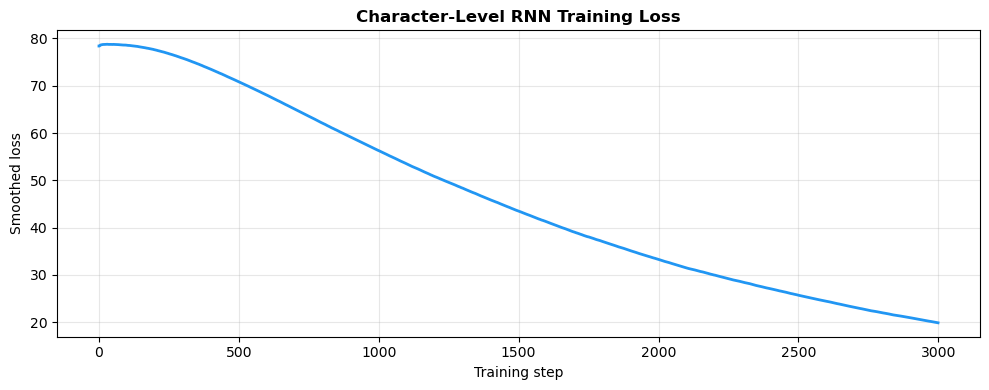


Final generated text (200 chars):
   hello worl ng demberpling mederthat networy anembaw wow pleaticiteotw rhited aracint amemory thixplia tiat learng ecite at islin urememhdhdhet arecnas nep cal omext la prgrematinetwrrs and pre lee nal


In [7]:
# Train the character-level RNN
SEQ_LEN   = 25
rnn       = VanillaRNN(V, H, V, lr=0.1)
h_prev    = np.zeros((H, 1))
losses    = []
smooth    = None

data = [vocab[c] for c in text]
p    = 0

print('Training character-level RNN...')
for step in range(3000):
    if p + SEQ_LEN + 1 >= len(data):
        p = 0; h_prev = np.zeros((H, 1))

    inputs  = data[p : p + SEQ_LEN]
    targets = data[p+1 : p + SEQ_LEN + 1]

    loss, grads, h_prev = rnn.loss_and_grads(inputs, targets, h_prev)
    rnn.update(grads)

    smooth = loss if smooth is None else 0.999 * smooth + 0.001 * loss
    losses.append(smooth)
    p += SEQ_LEN

    if step % 500 == 0:
        sample = rnn.sample(h_prev, data[p], n=60)
        print(f'  Step {step:>4} | loss={smooth:.3f} | sample: "{sample}"')

# Plot loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, color='#2196F3', lw=2)
ax.set_xlabel('Training step'); ax.set_ylabel('Smoothed loss')
ax.set_title('Character-Level RNN Training Loss', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nFinal generated text (200 chars):')
print('  ', rnn.sample(np.zeros((H,1)), vocab['h'], n=200))

## 6. PyTorch RNN — Sentiment Analysis

We build a word-level RNN classifier for sentiment analysis.  
Architecture:
```
  Words → Embedding (map each word to a dense vector)
        → RNN (process sequence, maintain hidden state)
        → Take last hidden state h_T
        → FC layer → sigmoid → positive/negative probability
```

In [8]:
if TORCH:

    # ── Simple synthetic sentiment dataset ───────────────────────────────────
    positive_words = ['good', 'great', 'excellent', 'amazing', 'wonderful',
                      'fantastic', 'love', 'best', 'happy', 'beautiful',
                      'enjoyed', 'liked', 'awesome', 'brilliant', 'outstanding']
    negative_words = ['bad', 'terrible', 'awful', 'horrible', 'worst',
                      'boring', 'hate', 'poor', 'disappointing', 'dreadful',
                      'waste', 'mediocre', 'dull', 'forgettable', 'disaster']
    neutral_words  = ['the', 'a', 'movie', 'film', 'was', 'is', 'it', 'very',
                      'quite', 'really', 'but', 'and', 'this', 'that', 'i']

    def make_review(label, length=8):
        pos_words  = label
        words  = np.random.choice(neutral_words, length-pos_words, replace=True).tolist()
        if label == 1:
            words += np.random.choice(positive_words, pos_words, replace=True).tolist()
        else:
            words += np.random.choice(negative_words, -label+2 if label < 0 else 3, replace=True).tolist()
        np.random.shuffle(words)
        return words

    np.random.seed(42)
    all_words = positive_words + negative_words + neutral_words
    word2idx  = {w: i+1 for i, w in enumerate(all_words)}  # 0 = padding
    word2idx['<pad>'] = 0
    idx2word  = {i: w for w, i in word2idx.items()}
    vocab_size = len(word2idx)

    def encode_review(words, max_len=15):
        ids = [word2idx.get(w, 0) for w in words[:max_len]]
        ids += [0] * (max_len - len(ids))   # pad
        return ids

    N_PER_CLASS = 500
    MAX_LEN = 15

    X_data, y_data = [], []
    for _ in range(N_PER_CLASS):
        r_pos = make_review(3)
        r_neg = ['not' if np.random.rand() < 0.1 else w for w in make_review(-2)]
        X_data.append(encode_review(r_pos))
        y_data.append(1)
        X_data.append(encode_review(r_neg))
        y_data.append(0)

    X = torch.LongTensor(X_data)
    y = torch.FloatTensor(y_data)

    # Split
    n_train = int(0.8 * len(X))
    ds = TensorDataset(X, y)
    tr_ds, te_ds = torch.utils.data.random_split(ds, [n_train, len(X)-n_train])
    tr_ld = DataLoader(tr_ds, batch_size=32, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=64, shuffle=False)

    print(f'Vocabulary size: {vocab_size}')
    print(f'Train: {n_train} | Test: {len(X)-n_train}')
    # Show a sample
    sample_x, sample_y = X_data[0], y_data[0]
    words = [idx2word[i] for i in sample_x if i != 0]
    print(f'Sample: {words} → {"positive" if sample_y==1 else "negative"}')

Vocabulary size: 46
Train: 800 | Test: 200
Sample: ['i', 'worst', 'it', 'but', 'poor', 'this', 'film', 'dull'] → positive


Training sentiment RNNs...
Unidirectional RNN             final_acc=99.5%
Bidirectional RNN              final_acc=100.0%


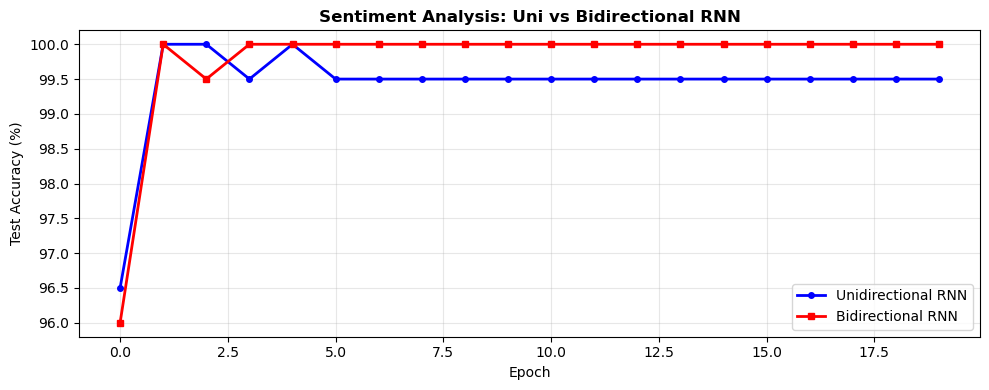


Custom predictions:
  [POSITIVE 100%] "the movie was great and wonderful"
  [POSITIVE 100%] "terrible boring waste of time"
  [POSITIVE 100%] "not great but not terrible"
  [POSITIVE 100%] "best film i have ever watched brilliant"


In [9]:
if TORCH:

    class SentimentRNN(nn.Module):
        """
        RNN-based sentiment classifier.

        Architecture:
          Embedding(vocab_size, embed_dim)
          → RNN(embed_dim, hidden_dim, num_layers, bidirectional)
          → take last hidden state h_T
          → Dropout → FC → Sigmoid
        """
        def __init__(self, vocab_size, embed_dim=32, hidden_dim=64,
                     n_layers=2, bidirectional=False, dropout=0.3):
            super().__init__()
            self.bidirectional = bidirectional
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.rnn = nn.RNN(
                embed_dim, hidden_dim, num_layers=n_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=dropout if n_layers > 1 else 0,
            )
            fc_in = hidden_dim * (2 if bidirectional else 1)
            self.fc = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(fc_in, 1),
            )

        def forward(self, x):
            # x: (B, T) integer token ids
            embedded = self.embedding(x)           # (B, T, embed_dim)
            out, h_n = self.rnn(embedded)          # out: (B, T, H), h_n: (layers*dir, B, H)

            # Take the last hidden state from the last layer
            if self.bidirectional:
                # Concatenate forward and backward last hidden states
                h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (B, 2H)
            else:
                h_last = h_n[-1]   # (B, H)

            return self.fc(h_last).squeeze(1)   # (B,)


    # Compare unidirectional vs bidirectional RNN
    def train_sentiment(model, name, epochs=20):
        model = model.to(device)
        opt   = optim.Adam(model.parameters(), lr=1e-3)
        val_accs = []
        for epoch in range(epochs):
            model.train()
            for xb, yb in tr_ld:
                xb, yb = xb.to(device), yb.to(device)
                loss = F.binary_cross_entropy_with_logits(model(xb), yb)
                opt.zero_grad(); loss.backward(); opt.step()
            model.eval()
            correct = total = 0
            with torch.no_grad():
                for xb, yb in te_ld:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = (model(xb) > 0).float()
                    correct += (preds == yb).sum().item()
                    total   += len(yb)
            val_accs.append(correct/total*100)
        print(f'{name:<30} final_acc={val_accs[-1]:.1f}%')
        return val_accs

    uni_rnn  = SentimentRNN(vocab_size, bidirectional=False)
    bi_rnn   = SentimentRNN(vocab_size, bidirectional=True)

    print('Training sentiment RNNs...')
    uni_accs = train_sentiment(uni_rnn,  'Unidirectional RNN')
    bi_accs  = train_sentiment(bi_rnn,   'Bidirectional RNN')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(uni_accs, 'b-o', lw=2, markersize=4, label='Unidirectional RNN')
    ax.plot(bi_accs,  'r-s', lw=2, markersize=4, label='Bidirectional RNN')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Sentiment Analysis: Uni vs Bidirectional RNN', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Show predictions on custom inputs
    bi_rnn.eval()
    test_sentences = [
        'the movie was great and wonderful',
        'terrible boring waste of time',
        'not great but not terrible',
        'best film i have ever watched brilliant',
    ]
    print('\nCustom predictions:')
    for sent in test_sentences:
        ids = encode_review(sent.split(), max_len=MAX_LEN)
        x   = torch.LongTensor([ids]).to(device)
        with torch.no_grad():
            prob = torch.sigmoid(bi_rnn(x)).item()
        label = 'POSITIVE' if prob > 0.5 else 'NEGATIVE'
        print(f'  [{label} {prob:.0%}] "{sent}"')

## 7. Time Series Forecasting with RNNs

RNNs are natural for time series: use a window of past observations to predict the next value.

```
  Input sequence: [x_{t-T}, x_{t-T+1}, ..., x_{t-1}]
  Target:          x_t  (next value)

  Sliding window creates many training examples from one long series.
```

Time series length: 2000
Training sequences: 1568
Input shape: (1, 40, 1)

Training time series RNN...
  Epoch 10 | train_mse=0.1562 | val_mse=0.1414
  Epoch 20 | train_mse=0.1484 | val_mse=0.1116
  Epoch 30 | train_mse=0.1376 | val_mse=0.1117


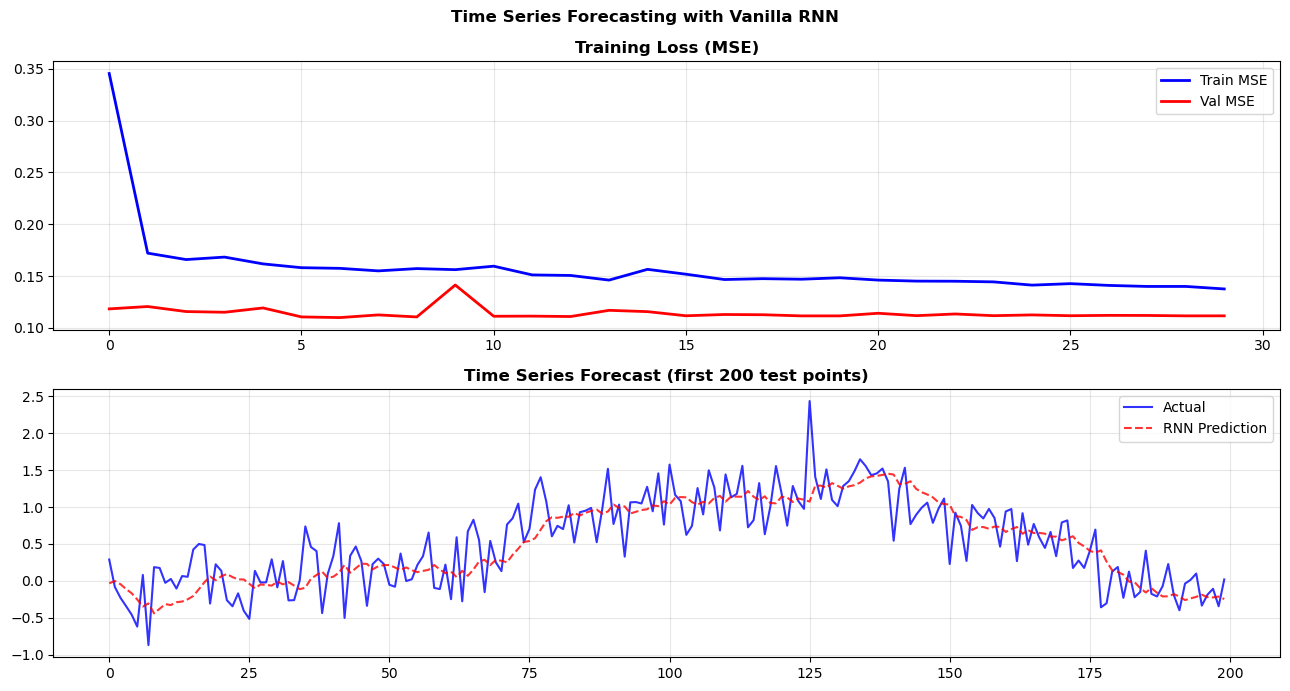

Test MSE: 0.1350  |  Test MAE: 0.2897


In [10]:
if TORCH:
    # Generate a synthetic multivariate time series
    T_total = 2000
    t = np.linspace(0, 8*np.pi, T_total)
    # Signal: damped oscillation + trend + noise
    signal = (np.sin(t) * np.exp(-0.05*t) +
              0.5*np.cos(2.3*t) +
              0.02*t +
              0.2*np.random.randn(T_total))

    # Normalize
    signal = (signal - signal.mean()) / signal.std()

    # Create sliding window dataset
    SEQ   = 40   # look-back window
    AHEAD = 1    # predict 1 step ahead

    Xs, ys = [], []
    for i in range(len(signal) - SEQ - AHEAD + 1):
        Xs.append(signal[i : i+SEQ])
        ys.append(signal[i+SEQ : i+SEQ+AHEAD])

    X_ts = torch.FloatTensor(Xs).unsqueeze(-1)  # (N, SEQ, 1)
    y_ts = torch.FloatTensor(ys)                # (N, AHEAD)

    n_train = int(0.8 * len(X_ts))
    tr_x, te_x = X_ts[:n_train], X_ts[n_train:]
    tr_y, te_y = y_ts[:n_train], y_ts[n_train:]

    tr_ld_ts = DataLoader(TensorDataset(tr_x, tr_y), batch_size=64, shuffle=True)
    te_ld_ts = DataLoader(TensorDataset(te_x, te_y), batch_size=128, shuffle=False)

    print(f'Time series length: {T_total}')
    print(f'Training sequences: {n_train}')
    print(f'Input shape: {tuple(X_ts[:1].shape)}')

    class TimeSeriesRNN(nn.Module):
        def __init__(self, input_size=1, hidden_size=64, n_layers=2, ahead=1):
            super().__init__()
            self.rnn = nn.RNN(input_size, hidden_size, n_layers,
                               batch_first=True, dropout=0.2)
            self.fc  = nn.Linear(hidden_size, ahead)

        def forward(self, x):
            out, h = self.rnn(x)   # out: (B, T, H)
            return self.fc(out[:, -1, :])   # use last timestep

    ts_model = TimeSeriesRNN().to(device)
    ts_opt   = optim.Adam(ts_model.parameters(), lr=1e-3, weight_decay=1e-5)
    ts_sch   = optim.lr_scheduler.CosineAnnealingLR(ts_opt, T_max=30)

    print('\nTraining time series RNN...')
    train_losses, val_losses = [], []
    for epoch in range(1, 31):
        ts_model.train()
        tl = 0
        for xb, yb in tr_ld_ts:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.mse_loss(ts_model(xb), yb)
            ts_opt.zero_grad(); loss.backward(); ts_opt.step()
            tl += loss.item()
        ts_sch.step()
        ts_model.eval()
        vl = 0
        with torch.no_grad():
            for xb, yb in te_ld_ts:
                xb, yb = xb.to(device), yb.to(device)
                vl += F.mse_loss(ts_model(xb), yb).item()
        train_losses.append(tl / len(tr_ld_ts))
        val_losses.append(vl / len(te_ld_ts))
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:>2} | train_mse={train_losses[-1]:.4f} | val_mse={val_losses[-1]:.4f}')

    # Visualise predictions
    ts_model.eval()
    with torch.no_grad():
        preds = ts_model(te_x.to(device)).cpu().numpy().ravel()
    actual = te_y.numpy().ravel()

    fig, axes = plt.subplots(2, 1, figsize=(13, 7))

    # Training curves
    axes[0].plot(train_losses, 'b-', lw=2, label='Train MSE')
    axes[0].plot(val_losses,   'r-', lw=2, label='Val MSE')
    axes[0].set_title('Training Loss (MSE)', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Predictions vs actuals
    show = min(200, len(actual))
    axes[1].plot(actual[:show],  'b-', lw=1.5, alpha=0.8, label='Actual')
    axes[1].plot(preds[:show],   'r--', lw=1.5, alpha=0.8, label='RNN Prediction')
    axes[1].set_title(f'Time Series Forecast (first {show} test points)', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Time Series Forecasting with Vanilla RNN', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    mse = np.mean((preds - actual)**2)
    mae = np.mean(np.abs(preds - actual))
    print(f'Test MSE: {mse:.4f}  |  Test MAE: {mae:.4f}')

## 8. Sequence Generation — Temperature Sampling

A trained language model outputs a probability distribution over the next token.  
**Temperature** controls the "creativity" of the samples:

$$p_i = \frac{\exp(z_i / \tau)}{\sum_j \exp(z_j / \tau)}$$

| Temperature τ | Effect |
|---|---|
| τ → 0 | Always pick the highest-probability token (greedy / deterministic) |
| τ = 1 | Sample from the original distribution |
| τ > 1 | More uniform — more random, creative, sometimes nonsensical |

Effect of temperature on generated text (char-level RNN):
  τ=0.2: "terrextte that network learning is fasting is as an urous what is is care pne th"
  τ=0.5: "t aliomp set prexuticarning cit saw rat cak learniatl predicthout whet co sat ne"
  τ=1.0: "to fred it sefrlefut ceplly world thone nerlicthat cemexplisaticis onetfors ngri"
  τ=1.5: "te logrefllo prodit  saw res ne sly rns as is car mal al nitwuttly wautmecwors a"
  τ=2.0: "tecicbeuthestictiistw yfrmesc ne the oned the teuthong coore leldnk beato mamiin"


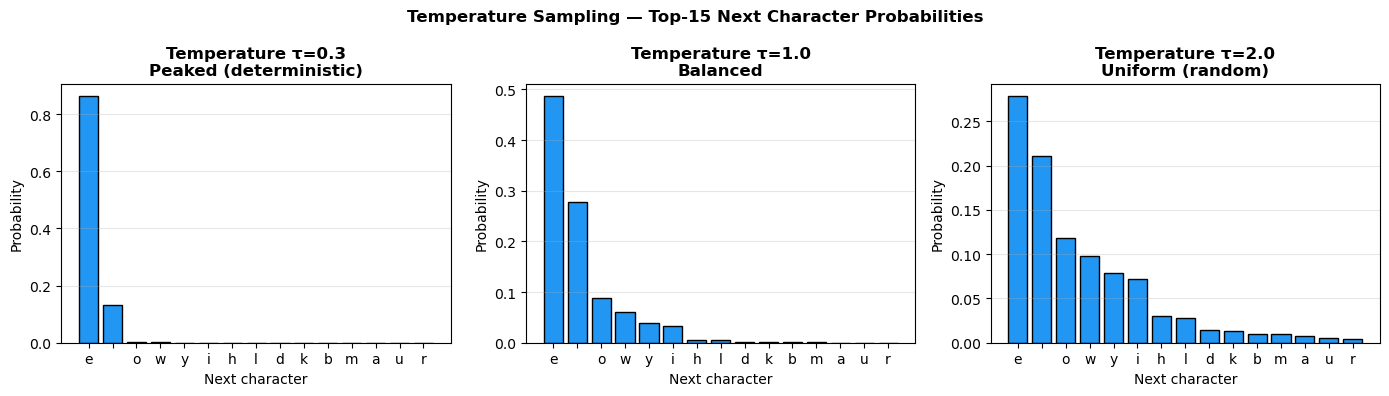

In [11]:
def sample_with_temperature(rnn, seed_char, n=100, temperature=1.0):
    """Sample from the character RNN with temperature."""
    h = np.zeros((H, 1))
    x = np.zeros((V, 1)); x[vocab[seed_char]] = 1
    out = [seed_char]

    for _ in range(n - 1):
        h = np.tanh(rnn.Wxh @ x + rnn.Whh @ h + rnn.bh)
        y = rnn.Why @ h + rnn.by

        # Apply temperature
        y_temp = y / temperature
        e      = np.exp(y_temp - y_temp.max())
        p      = (e / e.sum()).ravel()

        idx = np.random.choice(V, p=p)
        x   = np.zeros((V, 1)); x[idx] = 1
        out.append(idx2ch[idx])
    return ''.join(out)


temperatures = [0.2, 0.5, 1.0, 1.5, 2.0]
print('Effect of temperature on generated text (char-level RNN):')
print('=' * 65)
for temp in temperatures:
    sample = sample_with_temperature(rnn, 't', n=80, temperature=temp)
    print(f'  τ={temp:.1f}: "{sample}"')

# Visualise probability distributions
h_demo = np.zeros((H, 1))
x_demo = np.zeros((V, 1)); x_demo[vocab['t']] = 1
h_demo = np.tanh(rnn.Wxh @ x_demo + rnn.Whh @ h_demo + rnn.bh)
y_demo = (rnn.Why @ h_demo + rnn.by).ravel()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, temp in zip(axes, [0.3, 1.0, 2.0]):
    y_t = y_demo / temp
    e   = np.exp(y_t - y_t.max())
    p   = e / e.sum()
    sorted_idx = np.argsort(p)[::-1][:15]  # top 15 chars
    ax.bar([idx2ch[i] for i in sorted_idx], p[sorted_idx], color='#2196F3', edgecolor='black')
    ax.set_title(f'Temperature τ={temp}\n{"Peaked (deterministic)" if temp<0.5 else "Uniform (random)" if temp>1.5 else "Balanced"}',
                 fontweight='bold')
    ax.set_xlabel('Next character'); ax.set_ylabel('Probability')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Temperature Sampling — Top-15 Next Character Probabilities', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Limitations of Vanilla RNNs

Vanilla RNNs suffer from practical limitations that limit their use on real-world long sequences:

| Limitation | Description | Solution |
|---|---|---|
| **Vanishing gradient** | Gradients shrink exponentially over T steps | LSTM / GRU |
| **Exploding gradient** | Gradients grow exponentially | Gradient clipping |
| **Short memory** | Can't effectively use context from 50+ steps ago | LSTM / Attention |
| **Sequential computation** | Can't parallelize across timesteps | Transformers |
| **Slow training** | T sequential ops per forward pass | Transformers |

The gradient flow through T steps:

```python
  gradient = 1.0
  for step in range(T):
      gradient *= W_hh * tanh_derivative   # typically < 1

  # After T=100 steps: gradient ≈ (0.7)^100 ≈ 3×10⁻¹⁶  → vanished!
```

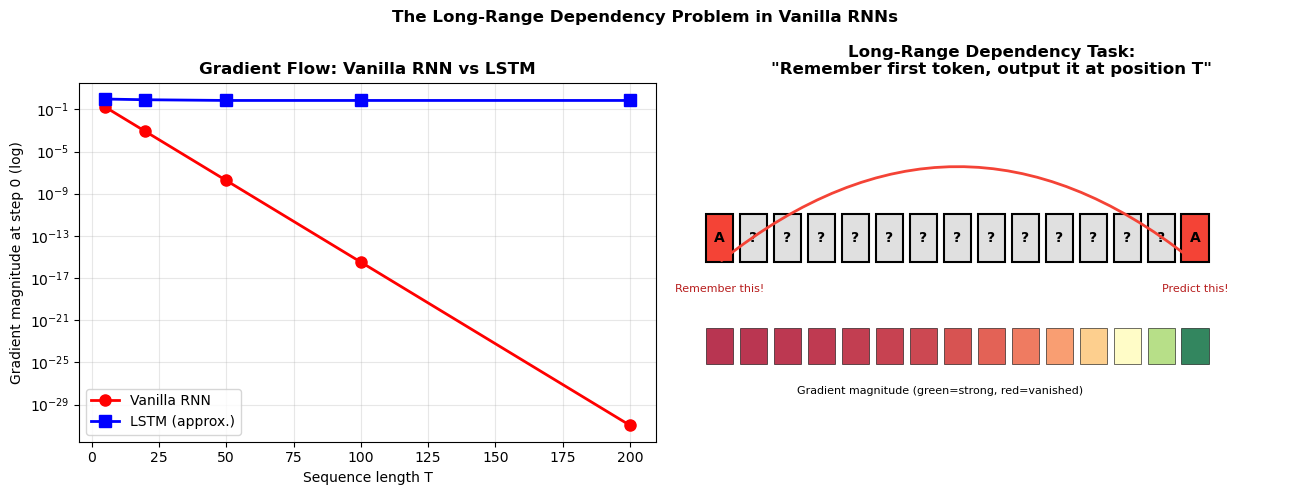


Conclusion:
  Vanilla RNNs: gradient decays as (0.7)^T ≈ 0 for T > 30
  → Cannot learn "remember token from 50 steps ago"
  → Solution: LSTM (Long Short-Term Memory) and GRU
  → Next notebook covers LSTM & GRU in detail.


In [12]:
# Visualise the long-range dependency problem
def test_long_range(sequence_lengths=[5, 20, 50, 100, 200]):
    """Show how accuracy drops as the dependency distance grows."""
    # Task: remember the first character and predict it at position T
    # This requires long-range memory
    results = {}

    for T in sequence_lengths:
        # Simulate expected gradient magnitude at step 0 (most distant)
        # for a vanilla RNN vs LSTM (conceptual)
        vanilla_grad = (0.7)**T   # typical gradient decay
        lstm_grad    = max(0.7, 0.99**T)   # LSTM maintains gradient much better
        results[T]   = (vanilla_grad, lstm_grad)

    T_vals = list(results.keys())
    v_grads = [results[T][0] for T in T_vals]
    l_grads = [results[T][1] for T in T_vals]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].semilogy(T_vals, v_grads, 'r-o', lw=2, markersize=8, label='Vanilla RNN')
    axes[0].semilogy(T_vals, l_grads, 'b-s', lw=2, markersize=8, label='LSTM (approx.)')
    axes[0].set_xlabel('Sequence length T')
    axes[0].set_ylabel('Gradient magnitude at step 0 (log)')
    axes[0].set_title('Gradient Flow: Vanilla RNN vs LSTM', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Illustration of the copy task
    T = 15
    ax = axes[1]
    ax.set_xlim(0, T+2); ax.set_ylim(-1, 5)
    ax.axis('off')
    ax.set_title('Long-Range Dependency Task:\n"Remember first token, output it at position T"',
                 fontweight='bold')

    seq = ['A'] + ['?'] * (T-2) + ['A']
    for i, c in enumerate(seq):
        color = '#F44336' if c == 'A' else '#E0E0E0'
        ax.add_patch(patches.Rectangle((i+0.1, 2.0), 0.8, 0.8,
                                        facecolor=color, edgecolor='black', lw=1.5))
        ax.text(i+0.5, 2.4, c, ha='center', va='center', fontsize=10, fontweight='bold')

    ax.text(0.5, 1.5, 'Remember this!', ha='center', fontsize=8, color='#B71C1C')
    ax.text(T-0.5, 1.5, 'Predict this!', ha='center', fontsize=8, color='#B71C1C')
    ax.annotate('', xy=(T-0.5, 2.0), xytext=(0.5, 2.0),
                arrowprops=dict(arrowstyle='->', color='#F44336', lw=2,
                                connectionstyle='arc3,rad=-0.4'))

    # Gradient flow boxes
    for i in range(T):
        grad_mag = min(1.0, (0.7)**i)
        color = plt.cm.RdYlGn(grad_mag)
        ax.add_patch(patches.Rectangle((T-1-i+0.1, 0.3), 0.8, 0.6,
                                        facecolor=color, edgecolor='black', lw=0.5, alpha=0.8))
    ax.text(T//2, -0.2, 'Gradient magnitude (green=strong, red=vanished)',
            ha='center', fontsize=8)

    plt.suptitle('The Long-Range Dependency Problem in Vanilla RNNs', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

test_long_range()

print('\nConclusion:')
print('  Vanilla RNNs: gradient decays as (0.7)^T ≈ 0 for T > 30')
print('  → Cannot learn "remember token from 50 steps ago"')
print('  → Solution: LSTM (Long Short-Term Memory) and GRU')
print('  → Next notebook covers LSTM & GRU in detail.')

## Summary

| Concept | Key Point |
|---|---|
| **Hidden state** | Vector that summarizes all past inputs — the RNN's "memory" |
| **Weight sharing** | Same W_hh, W_xh used at every timestep — works on any length |
| **BPTT** | Unroll the RNN in time, backprop like a deep network |
| **Vanishing gradient** | Exponential decay of gradients over T steps — core limitation |
| **Many-to-one** | Sequence classification (sentiment, topic) |
| **One-to-many** | Image captioning, music generation |
| **Many-to-many** | Translation, tagging, time series forecasting |
| **Temperature** | Controls randomness of samples from a language model |
| **Bidirectional** | Process sequence in both directions — better for NLU tasks |

### PyTorch RNN Cheat Sheet
```python
  rnn = nn.RNN(input_size, hidden_size, num_layers=2,
               batch_first=True, bidirectional=True, dropout=0.3)
  out, h_n = rnn(x)         # x: (B, T, D)
                             # out: (B, T, H*2)  — output at every step
                             # h_n: (L*2, B, H)  — final hidden state

  # For sentiment (many-to-one): use h_n[-1] or h_n[-2] cat h_n[-1]
  # For tagging (many-to-many): use out at every step
```

---
**Next notebook →** Gated Architectures (LSTM & GRU) — the solution to vanishing gradients: cell states, forget gates, and input gates.